# Predicción de Resultados de Liga MX con Random Forest
 
Libreta didáctica para Google Colab
## Objetivo
 
Aplicar Machine Learning supervisado para predecir resultados de partidos de Liga MX usando Random Forest.

In [1]:
import pandas as pd
import numpy as np

## Cargar dataset

In [2]:
df = pd.read_csv('dataset_liga_mx_jornadas_13_14_15_base.csv')
df.head()

,jornada,equipo_local,equipo_visita,resultado,local_puntos,visita_puntos,local_racha,visita_racha,local_posicion,visita_posicion,diff_puntos,diff_racha,diff_posicion
0,15,Mazatlán,Querétaro,1,12,16,2,4,17,13,-4,-2,-4
1,15,Atlético San Luis,Pumas,0,15,30,6,7,15,3,-15,-1,-12
2,15,Necaxa,Tigres,1,17,21,5,4,11,9,-4,1,-2
3,15,Cruz Azul,Tijuana,1,29,19,5,4,4,10,10,1,6
4,15,Monterrey,Pachuca,0,15,31,1,9,14,2,-16,-8,-12


## Selección de features

In [3]:
features = ['diff_puntos','diff_racha','diff_posicion']
X = df[features]
y = df['resultado']

## Entrenamiento del Random Forest

In [4]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

## Importancia de variables

In [5]:
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values(ascending=False)

diff_puntos      0.364355
diff_posicion    0.336094
diff_racha       0.299551
dtype: float64

## Visualización de un árbol

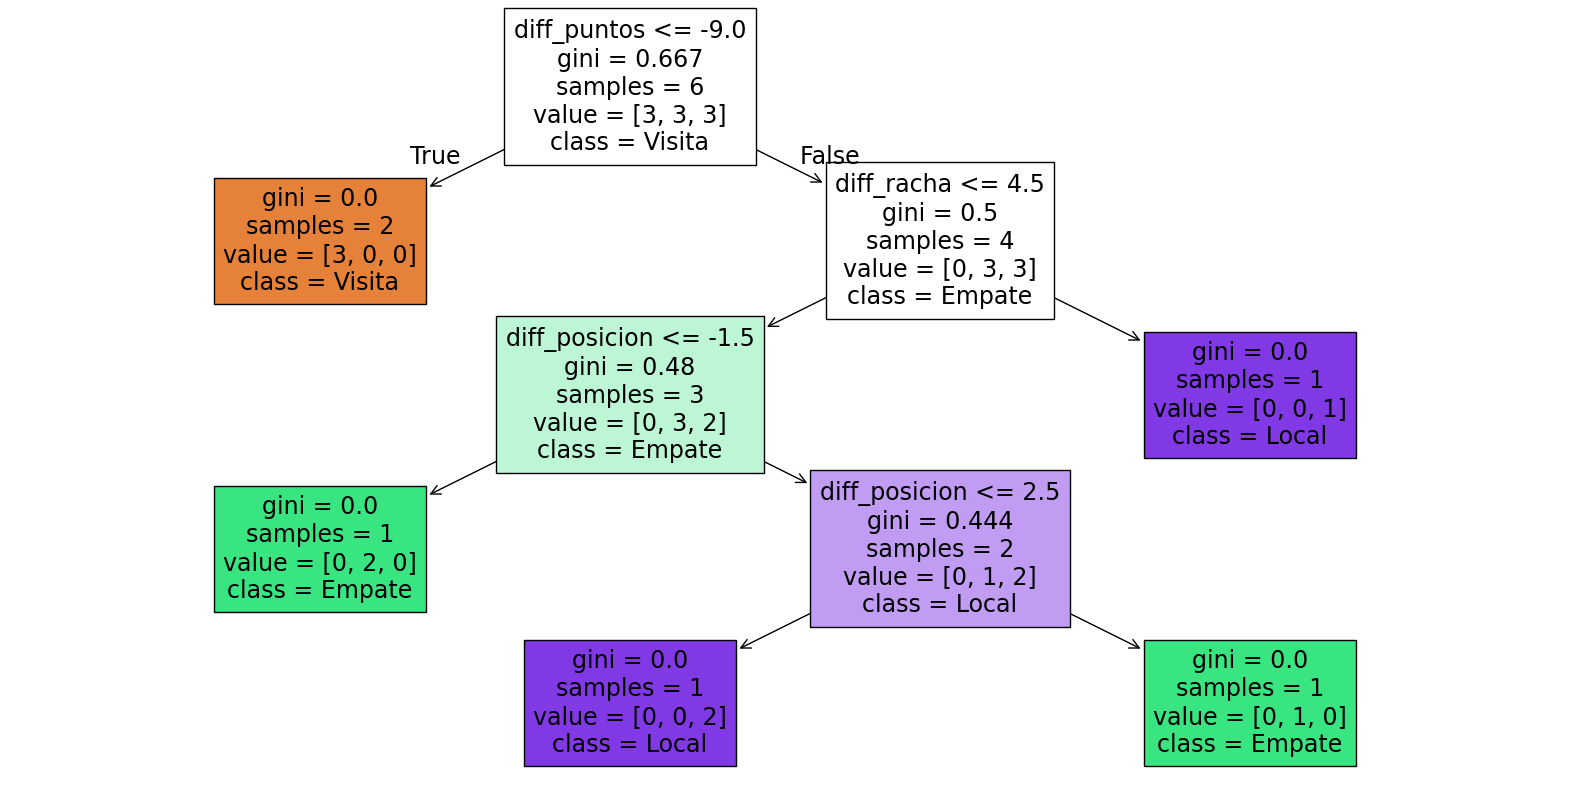

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], feature_names=features, class_names=['Visita','Empate','Local'], filled=True)
plt.show()

## Ética y uso responsable
Este modelo es educativo. No debe usarse para apuestas ni decisiones financieras.